In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/diabetes.csv')
print(df.shape)

(768, 9)


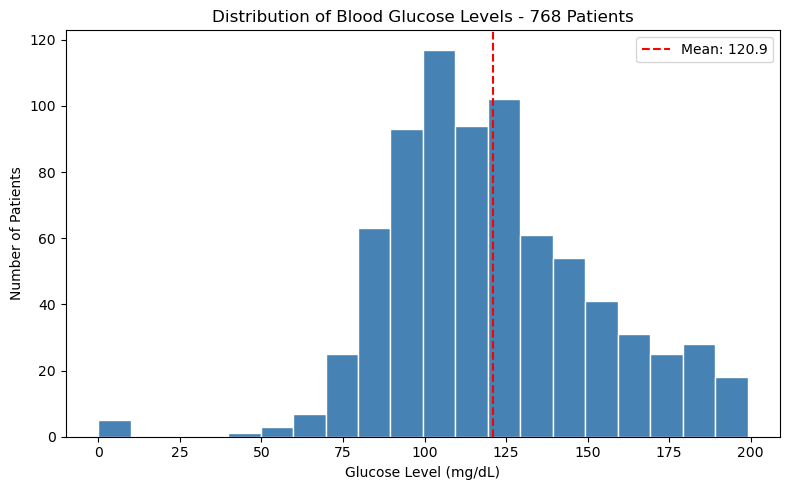

In [2]:
plt.figure(figsize=(8, 5))
plt.hist(df['Glucose'], bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Number of Patients')
plt.title('Distribution of Blood Glucose Levels - 768 Patients')
plt.axvline(df['Glucose'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df['Glucose'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.savefig('../data/glucose_histogram.png', dpi=150)
plt.show()

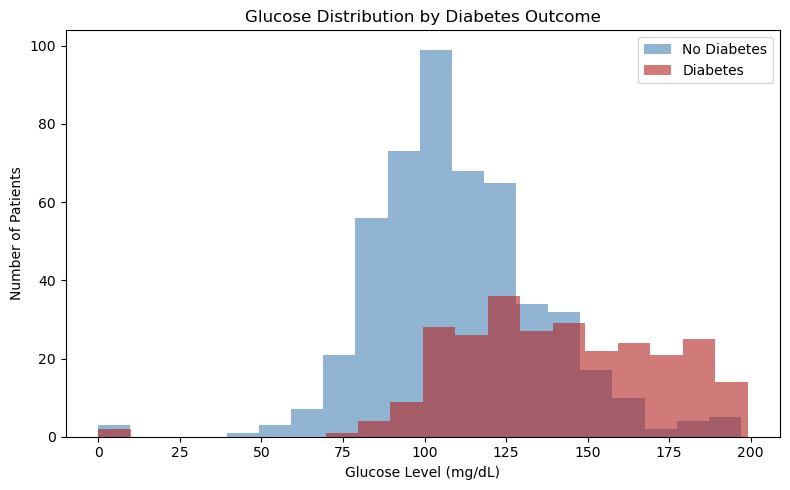

In [3]:
diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

plt.figure(figsize=(8, 5))
plt.hist(non_diabetic['Glucose'], bins=20, alpha=0.6, 
         color='steelblue', label='No Diabetes')
plt.hist(diabetic['Glucose'], bins=20, alpha=0.6, 
         color='firebrick', label='Diabetes')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Number of Patients')
plt.title('Glucose Distribution by Diabetes Outcome')
plt.legend()
plt.tight_layout()
plt.savefig('../data/glucose_by_outcome.png', dpi=150)
plt.show()

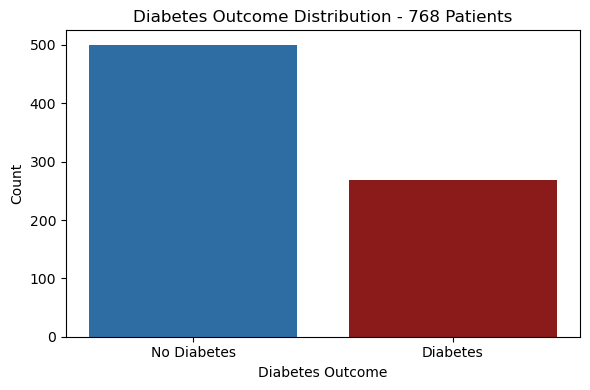

In [4]:
counts = df['Outcome'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['No Diabetes', 'Diabetes'], counts.values, 
        color=['#2E6DA4', '#8B1A1A'])
plt.ylabel('Count')
plt.xlabel('Diabetes Outcome')
plt.title('Diabetes Outcome Distribution - 768 Patients')
plt.tight_layout()
plt.savefig('../data/outcome_bar.png', dpi=150)
plt.show()

## Connecting Charts to Statistics — Day 17

Looking at the first histogram, the glucose distribution appears positively skewed. My first instinct was to doubt this, because most patients are clustered below the mean line (120.9) - which felt like it should mean something different. 

I corrected this by remembering that skew direction is identified by where the long tail is, not where most of the data sits. The left side of the chart drops to near zero quickly, but the right side has a long, gradually thinning tail stretching out to 200. That right-side tail is what makes this positively skewed - and it is also exactly what pulls the mean upward, above where most of the patients are actually clustered.

Comparing the two overlapping histograms, diabetic patients have glucose values shifted toward higher levels than non-diabetic patients. The red (diabetic) peak sits further right than the blue (non-diabetic) peak, with meaningful overlap between roughly 90 and 150 mg/dL.

Out of 768 total patients, approximately 500 have no diabetes and approximately 268 have diabetes - the dataset is imbalanced, with non-diabetic patients making up roughly two-thirds of the sample.

This is the first time I have seen Week 1 statistics concepts (skewness, mean, distribution shape) appear visually on real data. The skew confusion today was useful - it forced me to properly understand that skewness is about the tail, not the bulk of the data.